Task 1: Linear Regression
Develop predictive regression models using Linear Regression techniques for continuous-valued data analysis.
(Suggested Dataset: Boston Housing Dataset or equivalent)).

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


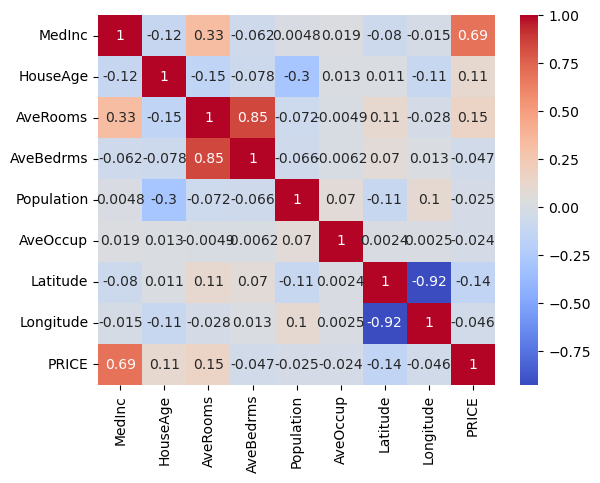


Model Evaluation
----------------
Mean Squared Error: 0.5558915986952442
Mean Absolute Error: 0.5332001304956557
R² Score: 0.575787706032451
Root Mean Squared Error (RMSE): 0.7455813830127763

Actual vs Predicted Prices:
   Actual Price  Predicted Price
0       0.47700         0.719123
1       0.45800         1.764017
2       5.00001         2.709659
3       2.18600         2.838926
4       2.78000         2.604657
5       1.58700         2.011754
6       1.98200         2.645500
7       1.57500         2.168755
8       3.40000         2.740746
9       4.46600         3.915615


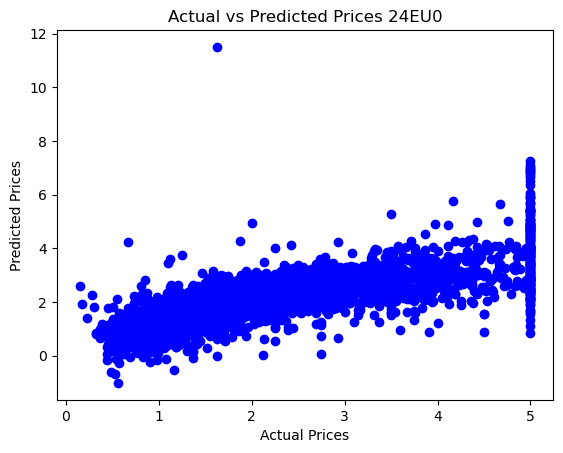

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

boston=fetch_california_housing()
df=pd.DataFrame(boston.data, columns=boston.feature_names)
df['PRICE'] = boston.target

print(df.head())
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

X=df.drop('PRICE',axis=1)
y=df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt( mean_squared_error(y_test, y_pred))
print("\nModel Evaluation")
print("----------------")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", rmse)
print("\nActual vs Predicted Prices:")
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})
print(results.head(10))

plt.scatter(y_test, y_pred, color="blue")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices 24EU0")
plt.show()

***Task 2: Comparative Models (SVR & Decision Tree Regression)
Implement Support Vector Regression (SVR) and Decision Tree Regression models for comparative performance analysis.***
*(Suggested Dataset: Boston Housing Dataset)*


Support Vector Regression Performance
-------------------------------------
MSE: 0.32450271430413125
MAE: 0.3737613005809912
R² Score: 0.7523653151859921

Decision Tree Regression Performance
-------------------------------------
MSE: 0.4972838079675652
MAE: 0.5008044131156354
R² Score: 0.6205125146233951


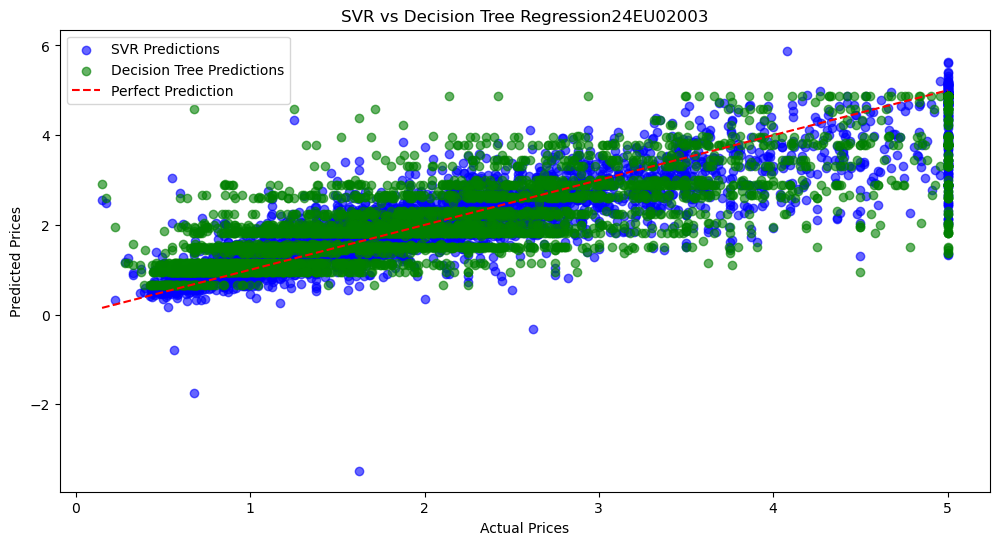

In [5]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)


print("\nSupport Vector Regression Performance")
print("-------------------------------------")
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("R² Score:", r2_score(y_test, y_pred_svr))


dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


print("\nDecision Tree Regression Performance")
print("-------------------------------------")
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("R² Score:", r2_score(y_test, y_pred_dt))


plt.figure(figsize=(12,6))

plt.scatter(y_test, y_pred_svr, color="blue", label="SVR Predictions", alpha=0.6)
plt.scatter(y_test, y_pred_dt, color="green", label="Decision Tree Predictions", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("SVR vs Decision Tree Regression24EU02003")
plt.legend()
plt.show()


Linear Regression Performance
----------------------------
MSE: 0.5558915986952442
MAE: 0.5332001304956557
R² Score: 0.575787706032451

Support Vector Regression Performance
----------------------------
MSE: 0.32450271430413125
MAE: 0.3737613005809912
R² Score: 0.7523653151859921

Decision Tree Regression Performance
----------------------------
MSE: 0.4972838079675652
MAE: 0.5008044131156354
R² Score: 0.6205125146233951


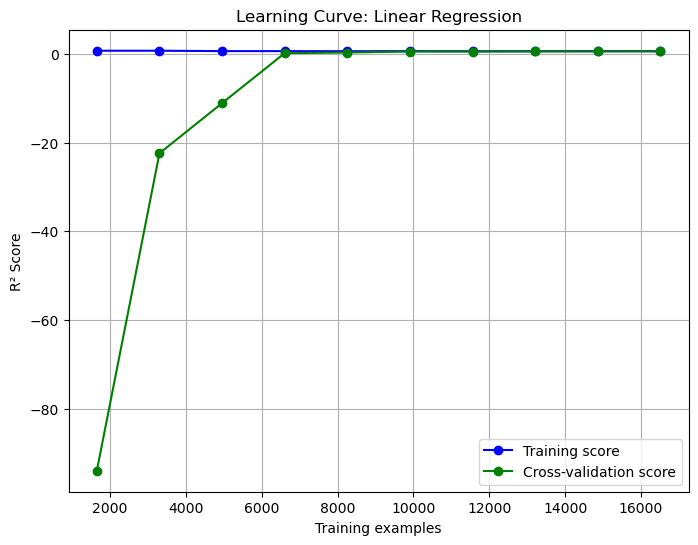

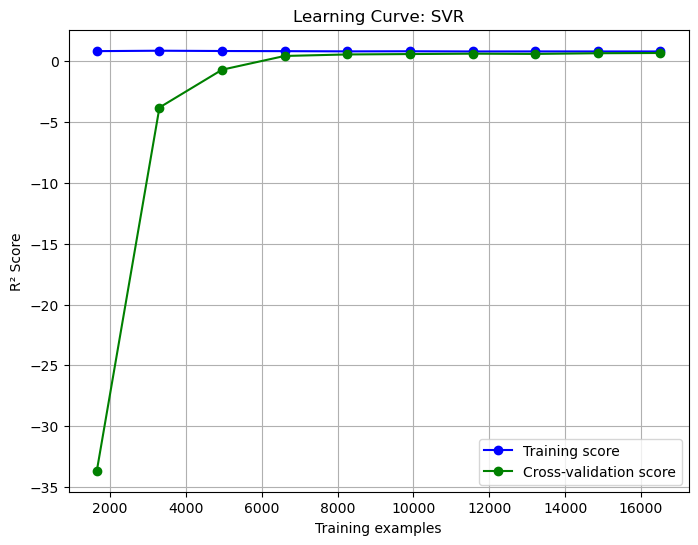

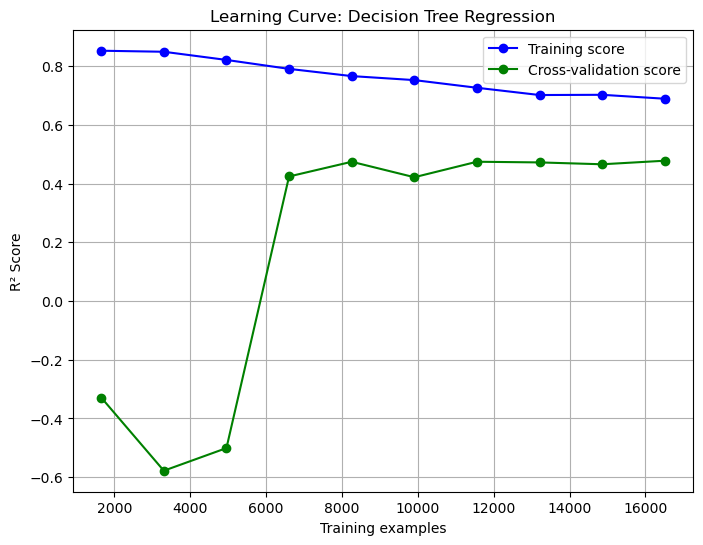

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load California Housing Dataset (replacement for Boston)
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    "Decision Tree Regression": DecisionTreeRegressor(max_depth=6, random_state=42)
}

# Function to evaluate models
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance")
    print("----------------------------")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R² Score:", r2_score(y_test, y_pred))
    return model

# Evaluate all models
for name, model in models.items():
    if name == "Support Vector Regression":
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)
    else:
        evaluate_model(name, model, X_train, X_test, y_train, y_test)

# -------------------------------
# Learning Curves
# -------------------------------
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring="r2", n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="green", label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("R² Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot learning curves for each model
plot_learning_curve(LinearRegression(), X, y, "Learning Curve: Linear Regression")
plot_learning_curve(SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1), StandardScaler().fit_transform(X), y, "Learning Curve: SVR")
plot_learning_curve(DecisionTreeRegressor(max_depth=6, random_state=42), X, y, "Learning Curve: Decision Tree Regression")
